In [40]:
import numpy as np
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import pandas as pd
df1 = pd.read_csv("metrics_native.csv", header=0)
df2 = pd.read_csv("metrics_browser.csv", header=0)
df3 = pd.read_csv("metrics_native12.csv", header=0)

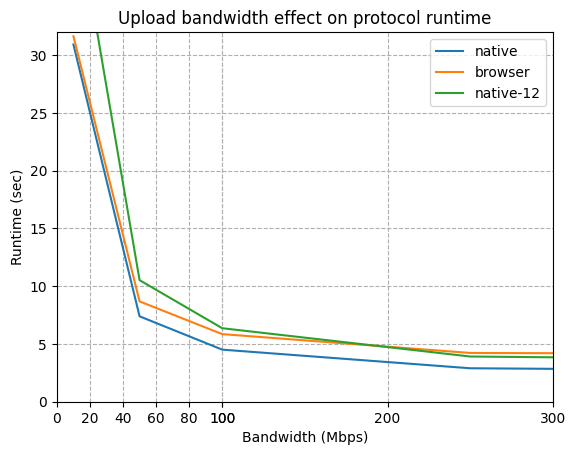

In [42]:
plt.style.use("default")

df1_filter = df1[df1["group"] == "bandwidth"].copy()
df2_filter = df2[df2["group"] == "bandwidth"].copy()
df3_filter = df3[df3["group"] == "bandwidth"].copy()

agg1 = df1_filter.groupby("bandwidth")["time_total"].mean().reset_index()
agg2 = df2_filter.groupby("bandwidth")["time_total"].mean().reset_index()
agg3 = df3_filter.groupby("bandwidth")["time_total"].mean().reset_index()

plt.plot(agg1["bandwidth"], agg1["time_total"]/1000.0, label="native")
plt.plot(agg2["bandwidth"], agg2["time_total"]/1000.0, label="browser")
plt.plot(agg3["bandwidth"], agg3["time_total"]/1000.0, label="native-12")

plt.xticks(list(range(0, 120, 20)) + list(range(100, 400, 100)) )


plt.xlim(0, 300)
plt.ylim(0, 32)
plt.xlabel("Bandwidth (Mbps)")
plt.ylabel("Runtime (sec)")
plt.title("Upload bandwidth effect on protocol runtime")
plt.legend(loc="upper right") 

plt.grid(True, linestyle="--")
plt.savefig("bandwidth.svg", bbox_inches="tight")
plt.show()

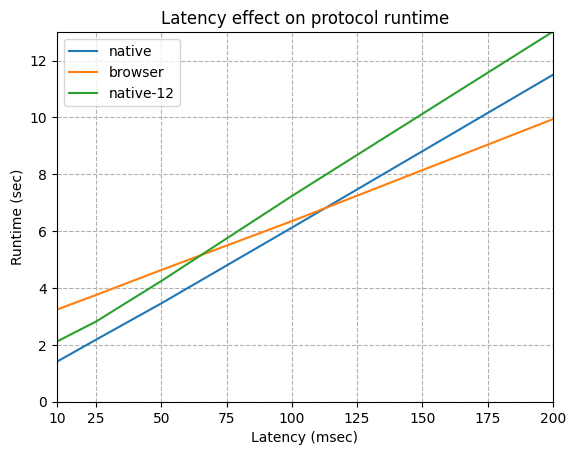

In [43]:
plt.style.use("default")

df1_filter = df1[df1["group"] == "latency"].copy()
df2_filter = df2[df2["group"] == "latency"].copy()
df3_filter = df3[df3["group"] == "latency"].copy()

agg1 = df1_filter.groupby("latency")["time_total"].mean().reset_index()
agg2 = df2_filter.groupby("latency")["time_total"].mean().reset_index()
agg3 = df3_filter.groupby("latency")["time_total"].mean().reset_index()

plt.plot(agg1["latency"], agg1["time_total"]/1000.0, label="native")
plt.plot(agg2["latency"], agg2["time_total"]/1000.0, label="browser")
plt.plot(agg3["latency"], agg3["time_total"]/1000.0, label="native-12")

plt.xlim(10, 200)
plt.ylim(0, 13)

# force ticks, otherwise 10 is not displayed
plt.xticks([10] + list(range(25, 201, 25)))

plt.xlabel("Latency (msec)")
plt.ylabel("Runtime (sec)")
plt.title("Latency effect on protocol runtime")
plt.legend(loc="upper left") 

plt.grid(True, linestyle="--")

plt.savefig("latency.svg", bbox_inches="tight")
plt.show()

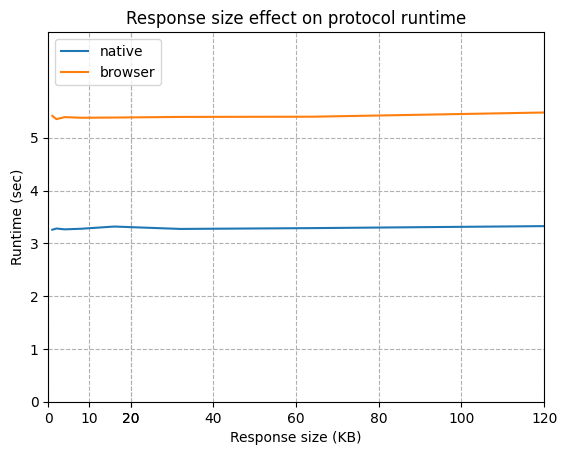

In [ ]:
plt.style.use("default")

df1_filter = df1[df1["group"] == "download_size"].copy()
df2_filter = df2[df2["group"] == "download_size"].copy()

agg1 = df1_filter.groupby("download_size")["time_total"].mean().reset_index()
agg2 = df2_filter.groupby("download_size")["time_total"].mean().reset_index()

plt.plot(agg1["download_size"]/1024.0, agg1["time_total"]/1000.0, label="native")
plt.plot(agg2["download_size"]/1024.0, agg2["time_total"]/1000.0, label="browser")

plt.xlabel("Response size (KB)")
plt.ylabel("Runtime (sec)")
plt.title("Response size effect on protocol runtime")
plt.legend(loc="upper left") 

plt.xticks(list(range(0, 30, 10)) + list(range(20,140, 20)) )
plt.yticks(list(range(0, 6, 1)))

plt.xlim(0, 120)
plt.ylim(0, 7)

plt.grid(True, linestyle="--")

plt.savefig("response_size.svg", bbox_inches="tight")
plt.show()